<a href="https://colab.research.google.com/github/madhav-iz/pneumothorax-detection/blob/main/pneumothorax_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install timm albumentations pydicom --quiet

In [ ]:
import os
import numpy as np
import pandas as pd
import cv2
import pydicom
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [ ]:
pip install opendatasets

In [ ]:
import opendatasets as od
od.download('https://www.kaggle.com/datasets/xhlulu/vinbigdata-chest-xray-resized-png-1024x1024')

Skipping, found downloaded files in "./vinbigdata-chest-xray-resized-png-1024x1024" (use force=True to force download)


In [ ]:
dicom_dir = "/content/vinbigdata-chest-xray-resized-png-1024x1024/train"
png_dir = "./png_images"

os.makedirs(png_dir, exist_ok=True)

def process_and_save_image(image_path, save_path):
    # Read the image using OpenCV, assuming grayscale for X-ray images
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Warning: Could not read image {image_path}")
        return

    # Normalize image to 0-255 range and convert to uint8
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    img = img.astype("uint8")

    cv2.imwrite(save_path, img)

files = os.listdir(dicom_dir)

for file in tqdm(files[:5000]):  # limit for faster training initially
    image_path = os.path.join(dicom_dir, file)
    png_path = os.path.join(png_dir, file) # file is already a .png

    process_and_save_image(image_path, png_path)

100%|██████████| 5000/5000 [03:03<00:00, 27.24it/s]


In [ ]:
df = pd.read_csv("/content/vinbigdata-chest-xray-resized-png-1024x1024/train.csv")

# Pneumothorax class_id = 14
pneumo_df = df[df["class_id"] == 14]
pneumo_images = set(pneumo_df["image_id"])

all_images = df["image_id"].unique()

data = []
for img in all_images:
    label = 1 if img in pneumo_images else 0
    data.append([img + ".png", label])

binary_df = pd.DataFrame(data, columns=["image_id", "label"])

print(binary_df["label"].value_counts())

label
1    10606
0     4394
Name: count, dtype: int64


In [ ]:
import os
import pandas as pd

BASE_DIR = "/content/vinbigdata-chest-xray-resized-png-1024x1024"
TRAIN_DIR = os.path.join(BASE_DIR, "train")
TEST_DIR = os.path.join(BASE_DIR, "test")
META_PATH = os.path.join(BASE_DIR, "train.csv")

print(os.path.exists(TRAIN_DIR), TRAIN_DIR)
print(os.path.exists(TEST_DIR), TEST_DIR)
print(os.path.exists(META_PATH), META_PATH)

meta_df = pd.read_csv(META_PATH)
print(meta_df.head())
print(meta_df.columns)
print(meta_df.shape)

True /content/vinbigdata-chest-xray-resized-png-1024x1024/train
True /content/vinbigdata-chest-xray-resized-png-1024x1024/test
True /content/vinbigdata-chest-xray-resized-png-1024x1024/train.csv
                           image_id          class_name  class_id rad_id  \
0  50a418190bc3fb1ef1633bf9678929b3          No finding        14    R11   
1  21a10246a5ec7af151081d0cd6d65dc9          No finding        14     R7   
2  9a5094b2563a1ef3ff50dc5c7ff71345        Cardiomegaly         3    R10   
3  051132a778e61a86eb147c7c6f564dfe  Aortic enlargement         0    R10   
4  063319de25ce7edb9b1c6b8881290140          No finding        14    R10   

    x_min   y_min   x_max   y_max  
0     NaN     NaN     NaN     NaN  
1     NaN     NaN     NaN     NaN  
2   691.0  1375.0  1653.0  1831.0  
3  1264.0   743.0  1611.0  1019.0  
4     NaN     NaN     NaN     NaN  
Index(['image_id', 'class_name', 'class_id', 'rad_id', 'x_min', 'y_min',
       'x_max', 'y_max'],
      dtype='object')
(67914, 8)


In [ ]:
meta_df["image_id"] = meta_df["image_id"].astype(str)

pneumo_df = df[df["class_id"] == 14]
pneumo_images = set(pneumo_df["image_id"].unique())

all_images = [f.replace(".png", "") for f in os.listdir(TRAIN_DIR) if f.endswith(".png")]

labels = []
for img_id in all_images:
    label = 1 if img_id in pneumo_images else 0
    labels.append([img_id + ".png", label])

labels_df = pd.DataFrame(labels, columns=["image_id", "label"])
print(labels_df.head())
print(labels_df["label"].value_counts())

                               image_id  label
0  c9e8a6340100ac38692351714fb7712b.png      1
1  803e047ce22c14175d0631e947ed1599.png      0
2  2415d19465e30def974fc2c9747692d4.png      0
3  857ab59ae027e1e079d3c2d8e3809352.png      1
4  60f3f88acccc1801acb5bb2e66029ee7.png      1
label
1    10606
0     4394
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    labels_df,
    test_size=0.2,
    random_state=42,
    stratify=labels_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(train_df.shape, val_df.shape)

(12000, 2) (3000, 2)


In [ ]:
!pip install -q timm albumentations

In [ ]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import timm
import albumentations as A
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torch.optim import SGD
from albumentations.pytorch import ToTensorV2
from sklearn.metrics import roc_auc_score

In [ ]:
train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=15,
        p=0.5
    ),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
class VinPNGDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_name = self.df.loc[idx, "image_id"]
        label = self.df.loc[idx, "label"]

        img_path = os.path.join(self.img_dir, image_name)
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )
        image=clahe.apply(image)
        image = image[10:-10, 10:-10]
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

        if self.transform:
            image = self.transform(image=image)["image"]

        label = torch.tensor(label, dtype=torch.float32)
        return image, label

In [ ]:
train_dataset = VinPNGDataset(train_df, TRAIN_DIR, transform=train_transform)
val_dataset = VinPNGDataset(val_df, TRAIN_DIR, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)

sample_img, sample_lbl = train_dataset[0]
print(sample_img.shape, sample_lbl)

torch.Size([3, 224, 224]) tensor(1.)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = timm.create_model(
    "deit_base_patch16_224",
    pretrained=True,
    num_classes=1
)
model = model.to(device)

cuda


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
num_pos = train_df["label"].sum()
num_neg = len(train_df) - num_pos
pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = SGD(model.parameters(), lr= 1e-4, momentum=0.9,weight_decay=1e-4)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.unsqueeze(1).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.unsqueeze(1).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = torch.sigmoid(outputs)

            running_loss += loss.item()
            all_labels.extend(labels.cpu().numpy().ravel())
            all_probs.extend(probs.cpu().numpy().ravel())

    auc = roc_auc_score(all_labels, all_probs)
    return running_loss / len(loader), auc

In [ ]:
best_auc = 0.0
num_epochs = 10

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_auc = validate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Val AUC:    {val_auc:.4f}")

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), "/content/best_deit_vinbigdata_png.pth")
        print("Best model saved.")

Epoch 1/10
Train Loss: 0.2495
Val Loss:   0.1645
Val AUC:    0.9556
Best model saved.
Epoch 2/10
Train Loss: 0.1603
Val Loss:   0.1418
Val AUC:    0.9688
Best model saved.
Epoch 3/10
Train Loss: 0.1359
Val Loss:   0.1275
Val AUC:    0.9728
Best model saved.
Epoch 4/10
Train Loss: 0.1220
Val Loss:   0.1155
Val AUC:    0.9777
Best model saved.


KeyboardInterrupt: 

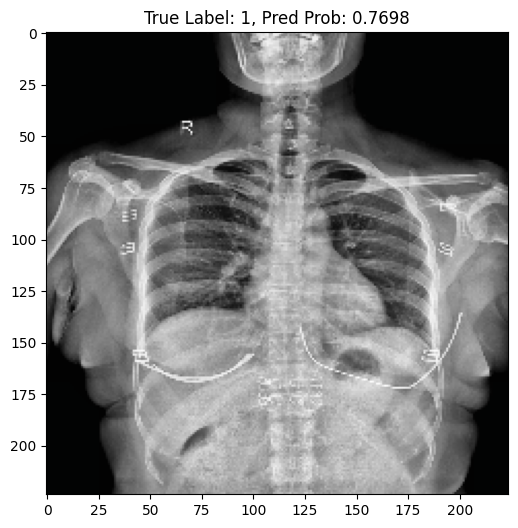

In [ ]:
model.load_state_dict(torch.load("/content/best_deit_vinbigdata_png.pth"))
model.eval()

image, label = val_dataset[484]

with torch.no_grad():
    output = model(image.unsqueeze(0).to(device))
    prob = torch.sigmoid(output).item()

img_np = image.permute(1, 2, 0).cpu().numpy()
img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img_np = np.clip(img_np, 0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(img_np)
plt.title(f"True Label: {int(label.item())}, Pred Prob: {prob:.4f}")
plt.axis()
plt.show()

In [ ]:
image, label = val_dataset[484]

input_tensor = image.unsqueeze(0).to(device)
input_tensor.requires_grad_()

tensor([[[[-2.0665, -2.0665, -2.0665,  ..., -2.0665, -2.0665, -2.0665],
          [-2.0665, -2.0665, -2.0665,  ..., -2.0665, -2.0665, -2.0665],
          [-2.0665, -2.0665, -2.0665,  ..., -2.0665, -2.0665, -2.0665],
          ...,
          [-2.0665, -2.0665, -2.0665,  ..., -2.0665, -2.0665, -2.0665],
          [-2.0665, -2.0665, -2.0665,  ..., -2.0665, -2.0665, -2.0665],
          [-2.0665, -2.0665, -2.0665,  ..., -2.0665, -2.0665, -2.0665]],

         [[-1.9832, -1.9832, -1.9832,  ..., -1.9832, -1.9832, -1.9832],
          [-1.9832, -1.9832, -1.9832,  ..., -1.9832, -1.9832, -1.9832],
          [-1.9832, -1.9832, -1.9832,  ..., -1.9832, -1.9832, -1.9832],
          ...,
          [-1.9832, -1.9832, -1.9832,  ..., -1.9832, -1.9832, -1.9832],
          [-1.9832, -1.9832, -1.9832,  ..., -1.9832, -1.9832, -1.9832],
          [-1.9832, -1.9832, -1.9832,  ..., -1.9832, -1.9832, -1.9832]],

         [[-1.7522, -1.7522, -1.7522,  ..., -1.7522, -1.7522, -1.7522],
          [-1.7522, -1.7522, -

In [ ]:
model.eval()

output = model(input_tensor)
score = torch.sigmoid(output)

In [ ]:
model.zero_grad()
score.backward()
saliency = input_tensor.grad.data.abs().squeeze().cpu().numpy()
saliency = saliency.max(axis=0)  # combine RGB channels
saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min())

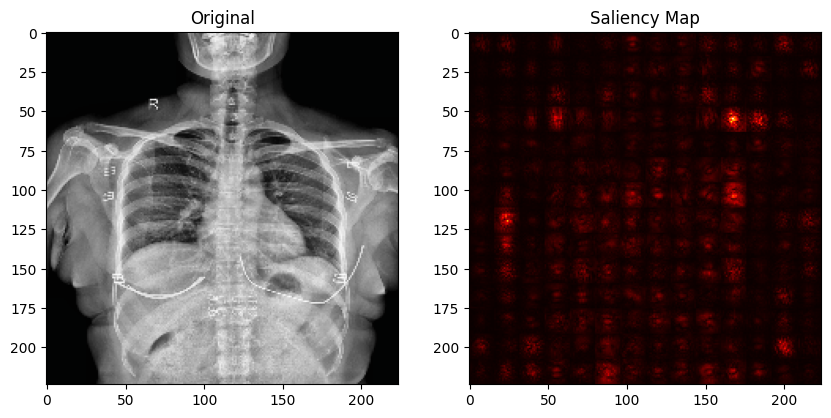

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

img = image.permute(1,2,0).cpu().numpy()

# denormalize
img = img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
img = np.clip(img, 0, 1)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(saliency, cmap='hot')
plt.title("Saliency Map")
plt.show()

In [ ]:
qkv_outputs = []

def hook_qkv(module, input, output):
    qkv_outputs.append(output)

for block in model.blocks:
    block.attn.qkv.register_forward_hook(hook_qkv)

In [ ]:
qkv_outputs = []

image, _ = val_dataset[5]
input_tensor = image.unsqueeze(0).to(device)

model.eval()
_ = model(input_tensor)

print(len(qkv_outputs))

12


In [ ]:
import torch

def get_attention_maps(qkv_outputs):
    attentions = []

    for qkv in qkv_outputs:
        B, N, C = qkv.shape

        qkv = qkv.reshape(B, N, 3, -1).permute(2, 0, 1, 3)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # compute attention
        attn = (q @ k.transpose(-2, -1)) / (k.shape[-1] ** 0.5)
        attn = attn.softmax(dim=-1)

        attentions.append(attn)

    return attentions

attentions = get_attention_maps(qkv_outputs)

print(attentions[0].shape)

torch.Size([1, 197, 197])


In [ ]:
def attention_rollout(attentions):
    result = torch.eye(attentions[0].shape[-1]).to(device)

    for attn in attentions:
        attn = attn.squeeze(0)
        attn = attn.mean(dim=0)

        attn = attn + torch.eye(attn.size(-1)).to(device)
        attn = attn / attn.sum(dim=-1, keepdim=True)

        result = torch.matmul(attn, result)

    return result

In [ ]:
rollout = attention_rollout(attentions)

mask = rollout[0, 1:]
size = int(mask.shape[0] ** 0.5)

mask = mask.reshape(size, size).cpu().detach().numpy()
mask = cv2.resize(mask, (224, 224))

In [ ]:
# normalize
mask = (mask - mask.min()) / (mask.max() - mask.min())

mask = np.power(mask, 3)   # sharper focus

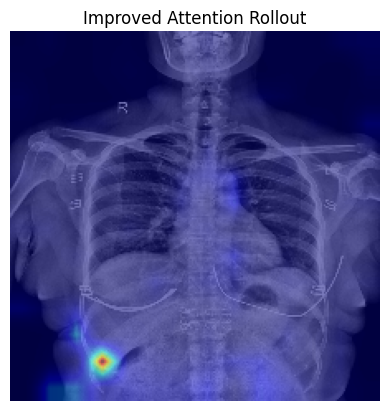

In [ ]:
plt.imshow(img)
plt.imshow(mask, cmap='jet', alpha=0.5)
plt.axis("off")
plt.title("Improved Attention Rollout")
plt.show()

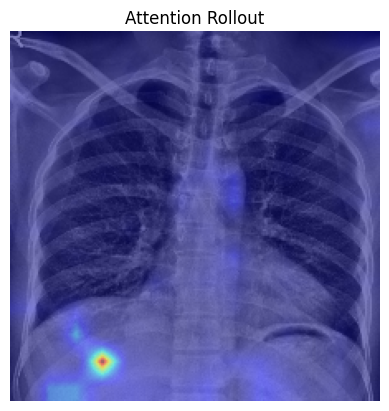

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

img = image.permute(1,2,0).cpu().numpy()
img = img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406])
img = np.clip(img, 0, 1)

plt.imshow(img)
plt.imshow(mask, cmap='jet', alpha=0.5)
plt.title("Attention Rollout")
plt.axis("off")
plt.show()